In [306]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

## 1.4

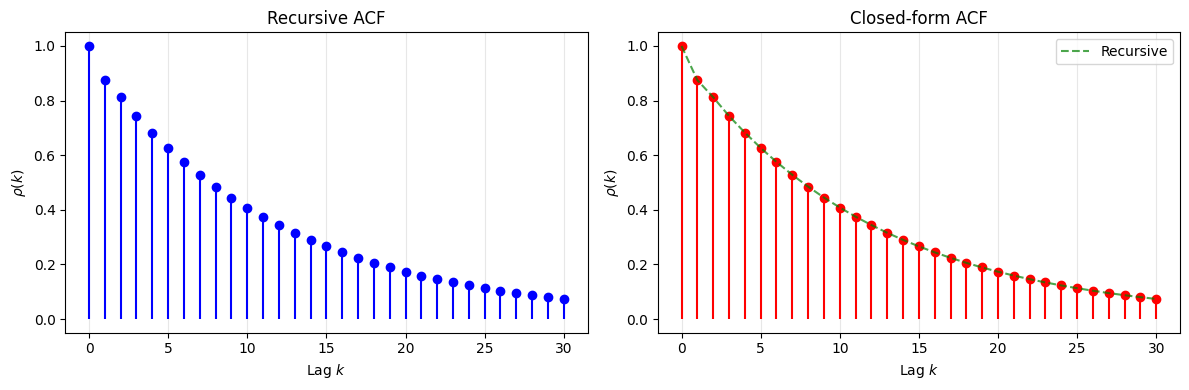

rho(1) = 0.8749999999999999
Roots: 0.9178908345800274 -0.21789083458002736
C1, C2: 0.9622367258209523 0.03776327417904768


In [307]:
# AR(2) parameters
phi1 = -0.7
phi2 = -0.2
max_lag = 30

# 1. Recursive ACF (explicit form)
def acf_recursive(phi1, phi2, max_lag):
    rho = np.zeros(max_lag + 1)
    rho[0] = 1.0
    rho[1] = -phi1 / (1 + phi2)
    for k in range(2, max_lag + 1):
        rho[k] = -phi1 * rho[k-1] - phi2 * rho[k-2]
    return rho

rho_rec = acf_recursive(phi1, phi2, max_lag)

# 2. Closed-form ACF verification
r = np.roots([1, phi1, phi2])  # Roots of char eq r^2 + phi1 r + phi2 = 0
r1, r2 = r[0], r[1]
rho1 = -phi1 / (1 + phi2)
C1 = (rho1 - r2) / (r1 - r2)
C2 = 1 - C1
rho_closed = C1 * r1**np.arange(max_lag+1) + C2 * r2**np.arange(max_lag+1)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

lags = np.arange(max_lag + 1)
ax1.stem(lags, rho_rec, basefmt=" ", linefmt="b-", markerfmt="bo")
# CORRECT:
ax1.set_ylabel(r"$\rho(k)$")
ax1.set_xlabel(r"Lag $k$")
ax1.set_title("Recursive ACF")
ax1.grid(True, axis="x", alpha=0.3)

ax2.stem(lags, rho_closed, basefmt=" ", linefmt="r-", markerfmt="ro")
ax2.plot(lags, rho_rec, "g--", alpha=0.7, label="Recursive")
# CORRECT:
ax2.set_ylabel(r"$\rho(k)$")
ax2.set_xlabel(r"Lag $k$")
ax2.set_title("Closed-form ACF")
ax2.legend()
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("acf_ar2.png", dpi=300, bbox_inches="tight")  # For report
plt.show()

print("rho(1) =", rho_rec[1])
print("Roots:", r1, r2)
print("C1, C2:", C1, C2)


## 2.1

In [308]:
n = 300          # final sample size (same for all models)

models = []


In [309]:
# 2.1: ARIMA(1,0,0)x(0,0,0)_12 → pure AR(1): phi1=0.6
print("2.1 AR(1): phi1=0.6")
ar1 = np.array([1, -0.6])
ma1 = np.array([1])
process1 = ArmaProcess(ar1, ma1)
y1 = process1.generate_sample(n)
models.append(('2.1 AR(1)', y1))


2.1 AR(1): phi1=0.6


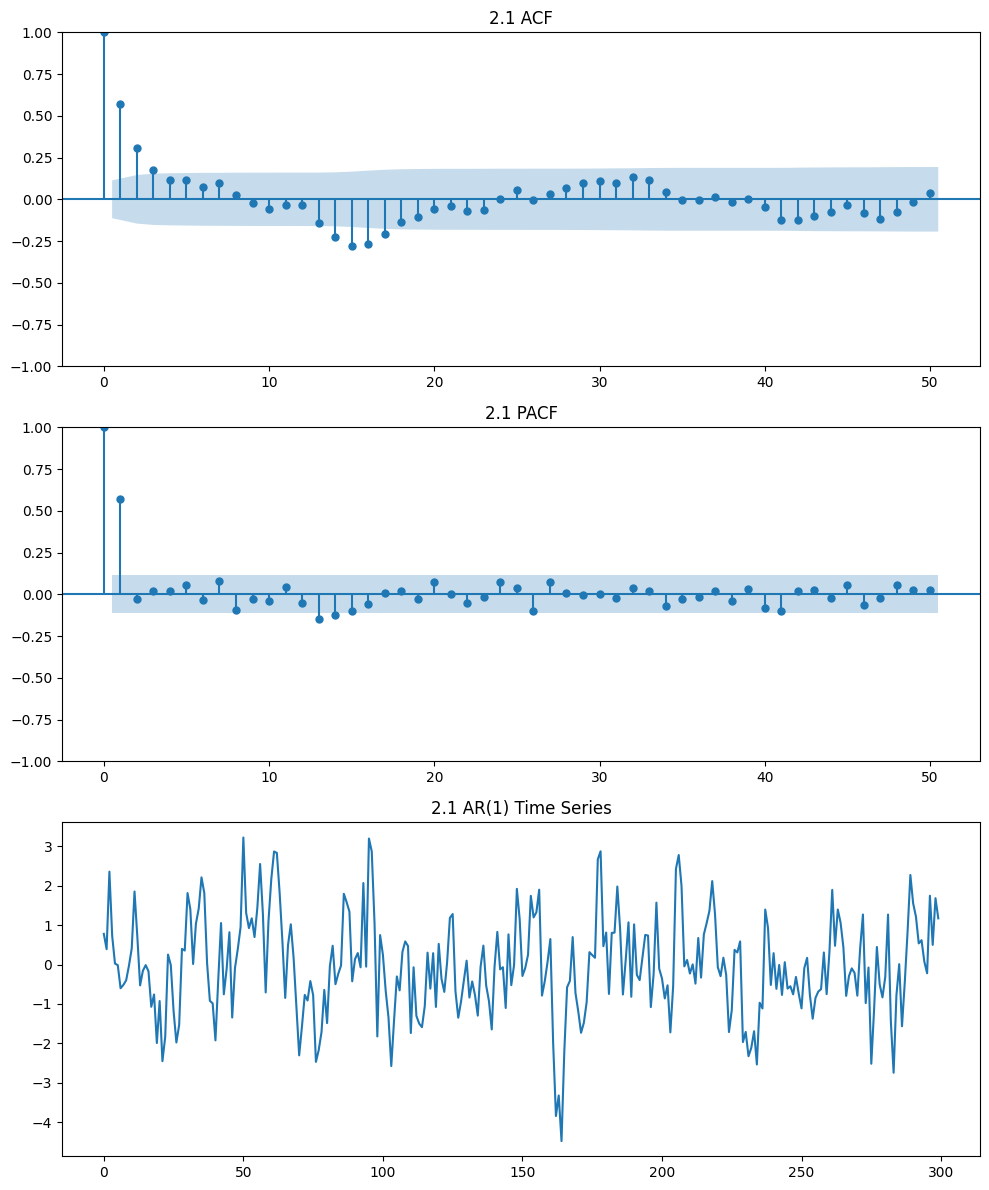

In [310]:
fig2_1, axes2_1 = plt.subplots(3, 1, figsize=(10, 12))
plot_acf(models[0][1], ax=axes2_1[0], lags=50); axes2_1[0].set_title("2.1 ACF")
plot_pacf(models[0][1], ax=axes2_1[1], lags=50); axes2_1[1].set_title("2.1 PACF")
plt.plot(models[0][1]); plt.title("2.1 AR(1) Time Series")
plt.tight_layout()
plt.savefig("2_1_individual.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.2

In [311]:
# 2.2: ARIMA(0,0,0)x(1,0,0)_12 → AR(12): seasonal AR(1) at lag 12, Phi1=-0.9
print("2.2 Seasonal AR(1): Phi1=-0.9")
ar12 = np.r_[1, np.zeros(11), 0.9]  # 1 + 0.9 B^12
ma12 = np.array([1])
process12 = ArmaProcess(ar12, ma12)
y12 = process12.generate_sample(n)
models.append(('2.2 SAR(1)', y12))

2.2 Seasonal AR(1): Phi1=-0.9


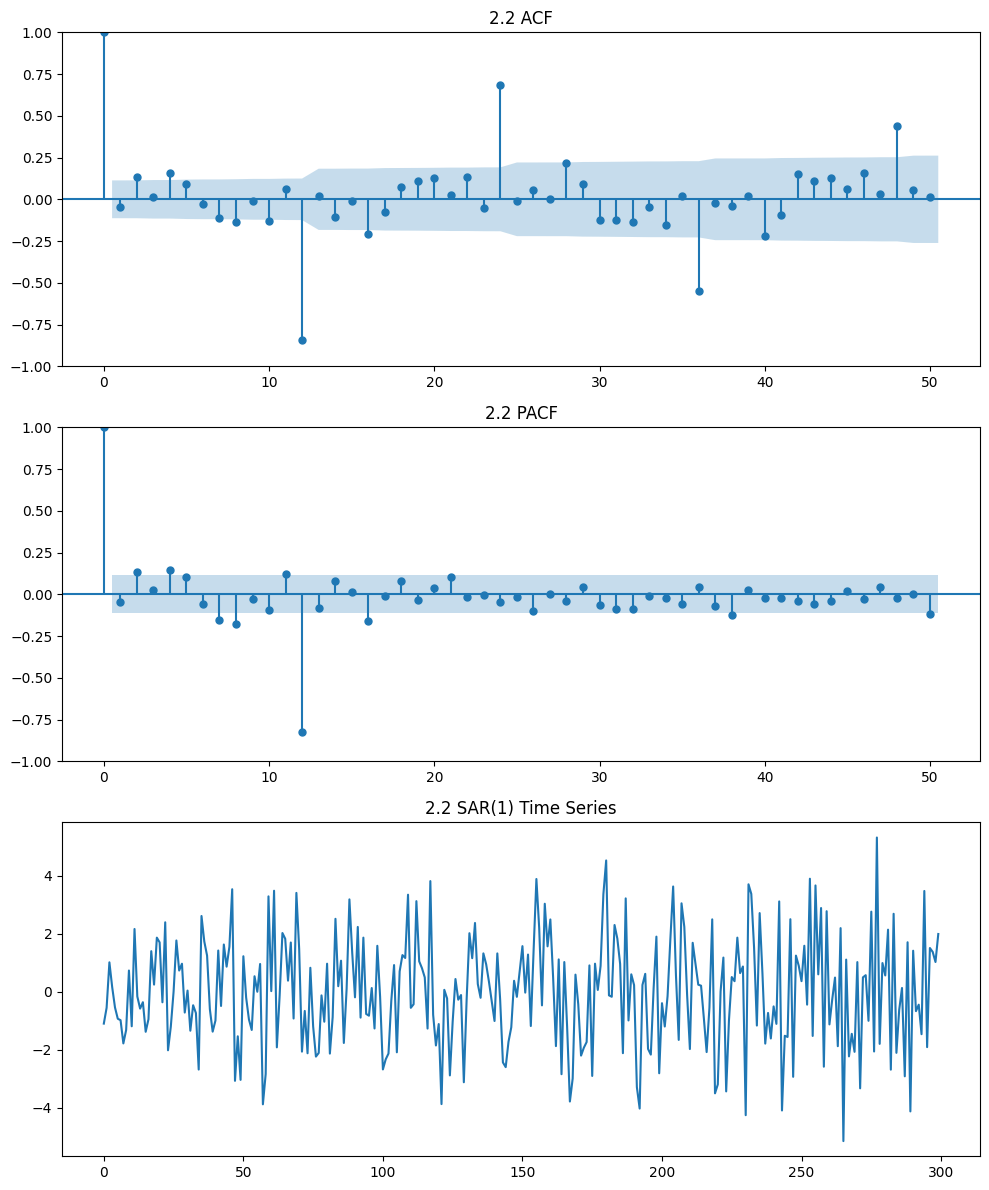

In [312]:
fig2_2, axes2_2 = plt.subplots(3, 1, figsize=(10, 12))
plot_acf(models[1][1], ax=axes2_2[0], lags=50); axes2_2[0].set_title("2.2 ACF")
plot_pacf(models[1][1], ax=axes2_2[1], lags=50); axes2_2[1].set_title("2.2 PACF")
plt.plot(models[1][1]); plt.title("2.2 SAR(1) Time Series")
plt.tight_layout()
plt.savefig("2_2_individual.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.3

In [313]:
# 2.3: ARIMA(1,0,0)x(0,0,1)_12 → ARMA(1,13): phi1=0.9, seasonal MA at lag 12: Theta1=-0.7
print("2.3 ARMA(1,13)")
ar13 = np.array([1, -0.9])  # AR(1)
ma13 = np.r_[1, np.zeros(11), 0.7]  # MA(13): theta_12 = -0.7 → +0.7 B^12 (sign flip!)
process13 = ArmaProcess(ar13, ma13)
y13 = process13.generate_sample(n)
models.append(('2.3 ARMA(1,13)', y13))

2.3 ARMA(1,13)


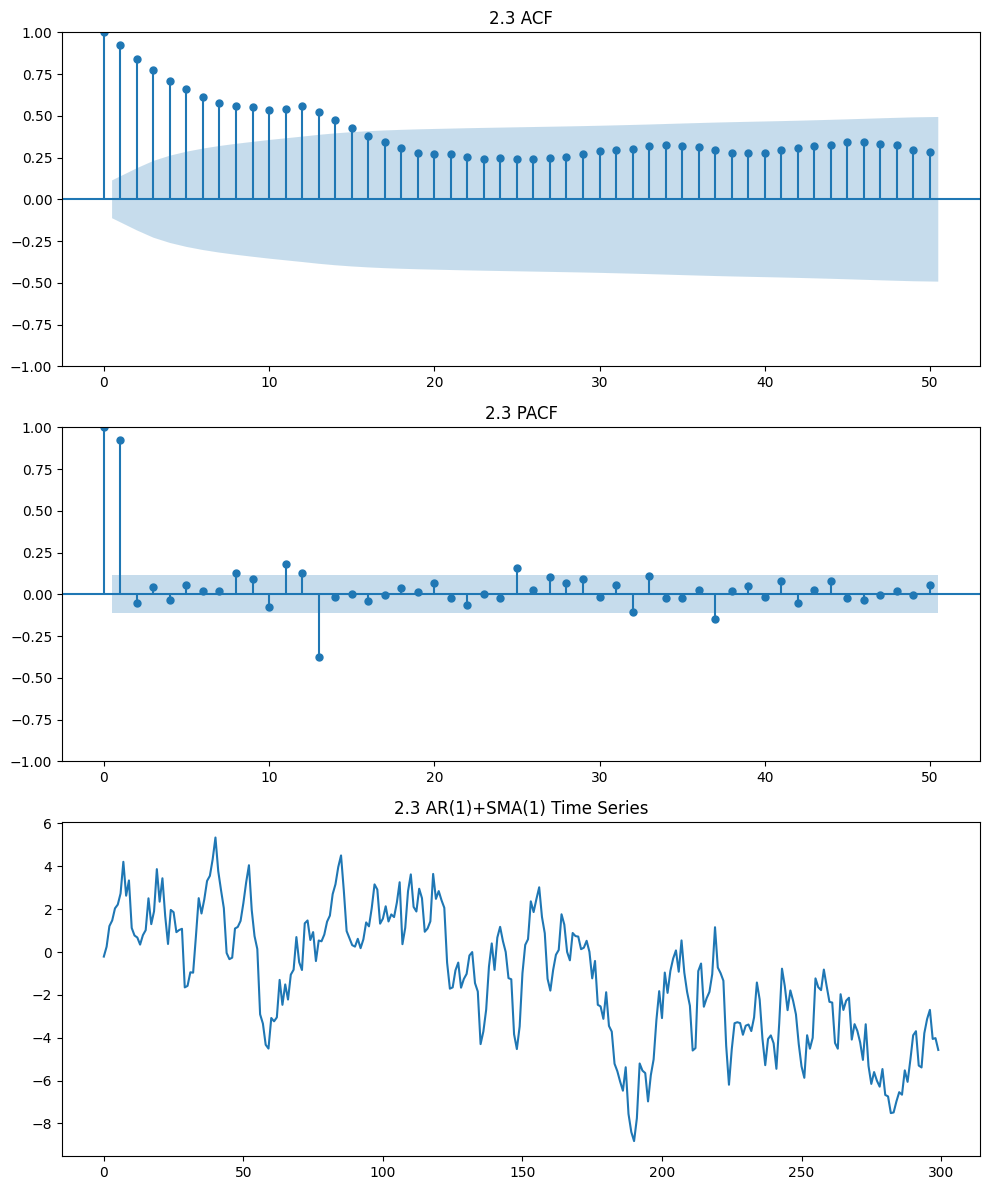

In [314]:
fig2_3, axes2_3 = plt.subplots(3, 1, figsize=(10, 12))
plot_acf(models[2][1], ax=axes2_3[0], lags=50); axes2_3[0].set_title("2.3 ACF")
plot_pacf(models[2][1], ax=axes2_3[1], lags=50); axes2_3[1].set_title("2.3 PACF")
plt.plot(models[2][1]); plt.title("2.3 AR(1)+SMA(1) Time Series")
plt.tight_layout()
plt.savefig("2_3_individual.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.4

In [315]:
burnin = 200     # extra samples to discard for model 2.4

In [316]:
# 2.4: ARIMA(1,0,0)x(1,0,0)_12 → AR(13): phi1=-0.6, Phi1=-0.8
print("2.4 AR(13)")
ar14 = np.r_[1, 0.6, np.zeros(10), 0.8, 0.48]
ma14 = np.array([1])
process14 = ArmaProcess(ar14, ma14)
y14_full = process14.generate_sample(n + burnin)
#y14 = y14_full[burnin:] # discard burn-in period
models.append(('2.4 AR(13)', y14_full))

2.4 AR(13)


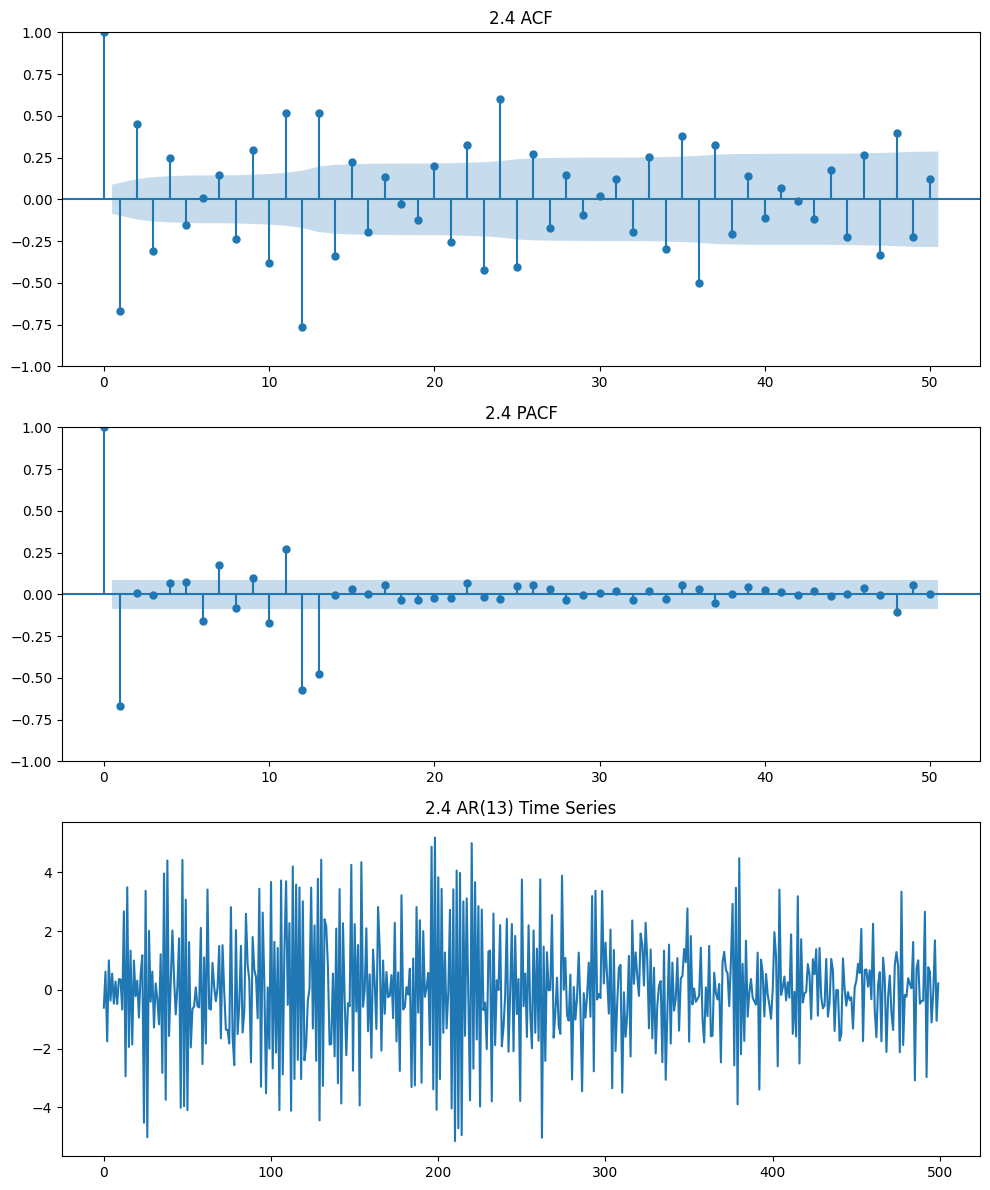

In [317]:
fig2_4, axes2_4 = plt.subplots(3, 1, figsize=(10, 12))
plot_acf(models[3][1], ax=axes2_4[0], lags=50); axes2_4[0].set_title("2.4 ACF")
plot_pacf(models[3][1], ax=axes2_4[1], lags=50); axes2_4[1].set_title("2.4 PACF")
plt.plot(models[3][1]); plt.title("2.4 AR(13) Time Series")
plt.tight_layout()
plt.savefig("2_4_individual.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.5 

In [318]:
print("2.5 MA(13)")
ar15 = np.array([1])
ma15 = np.r_[1, 0.4, np.zeros(10), -0.8, -0.32]   # theta_1=0.4→-0.4B, Theta_12=-0.8→+0.8B^12
process15 = ArmaProcess(ar15, ma15)
y15 = process15.generate_sample(n)
models.append(('2.5 MA(13)', y15))

2.5 MA(13)


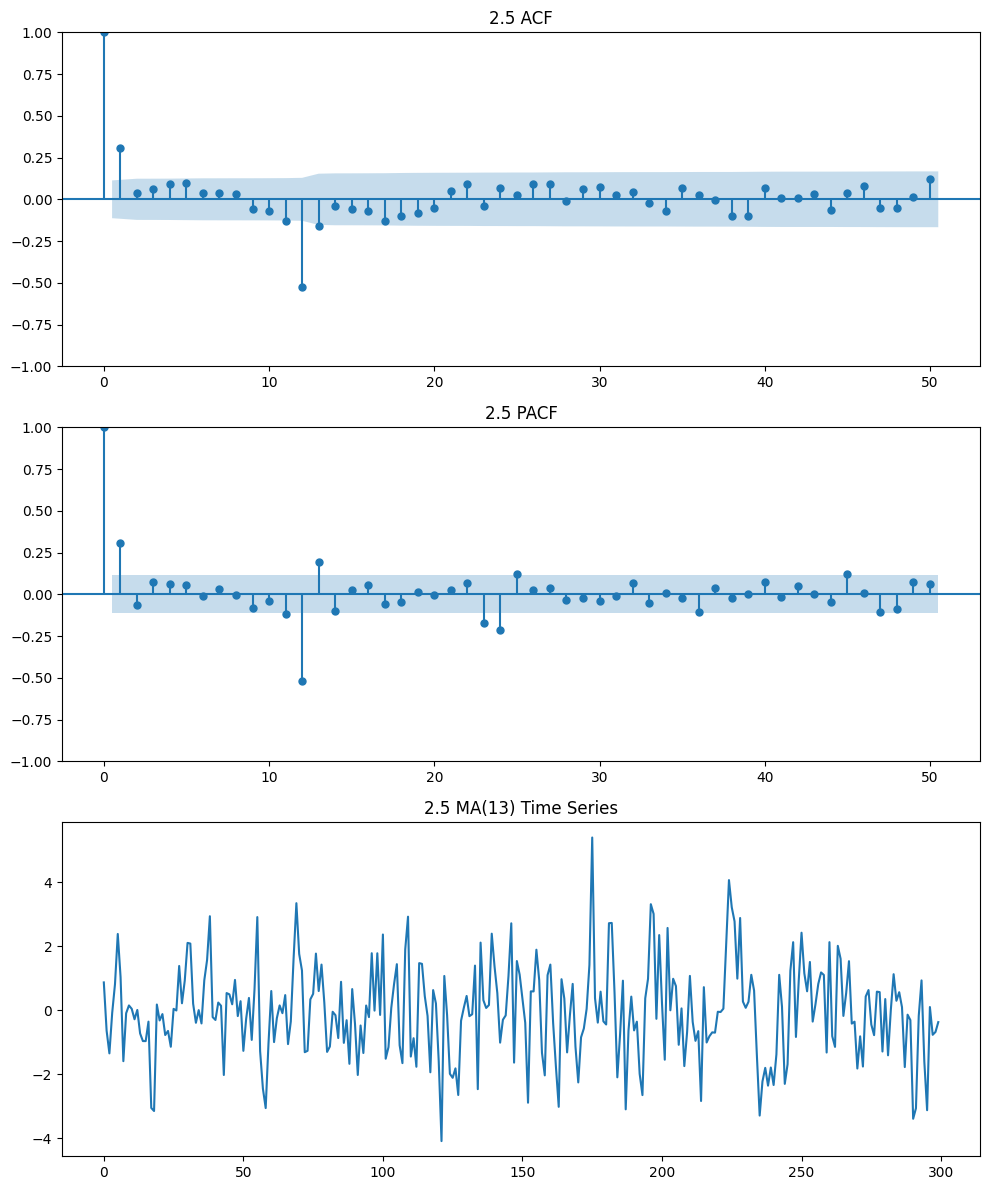

In [319]:
fig2_5, axes2_5 = plt.subplots(3, 1, figsize=(10, 12))
plot_acf(models[4][1], ax=axes2_5[0], lags=50); axes2_5[0].set_title("2.5 ACF")
plot_pacf(models[4][1], ax=axes2_5[1], lags=50); axes2_5[1].set_title("2.5 PACF")
plt.plot(models[4][1]); plt.title("2.5 MA(13) Time Series")
plt.tight_layout()
plt.savefig("2_5_individual.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.6

In [324]:
print("2.6 ARMA(13,1)")
ar16 = np.r_[1, np.zeros(11), -0.7]  # (1 - 0.7*B^12): sign flip → -0.7
ma16 = np.r_[1, 0.4, np.zeros(10)]   # (1 + 0.4*B): sign flip → +0.4
process16 = ArmaProcess(ar16, ma16)
y16 = process16.generate_sample(n)
models.append(('2.6 ARMA(13,1)', y16))

2.6 ARMA(13,1)


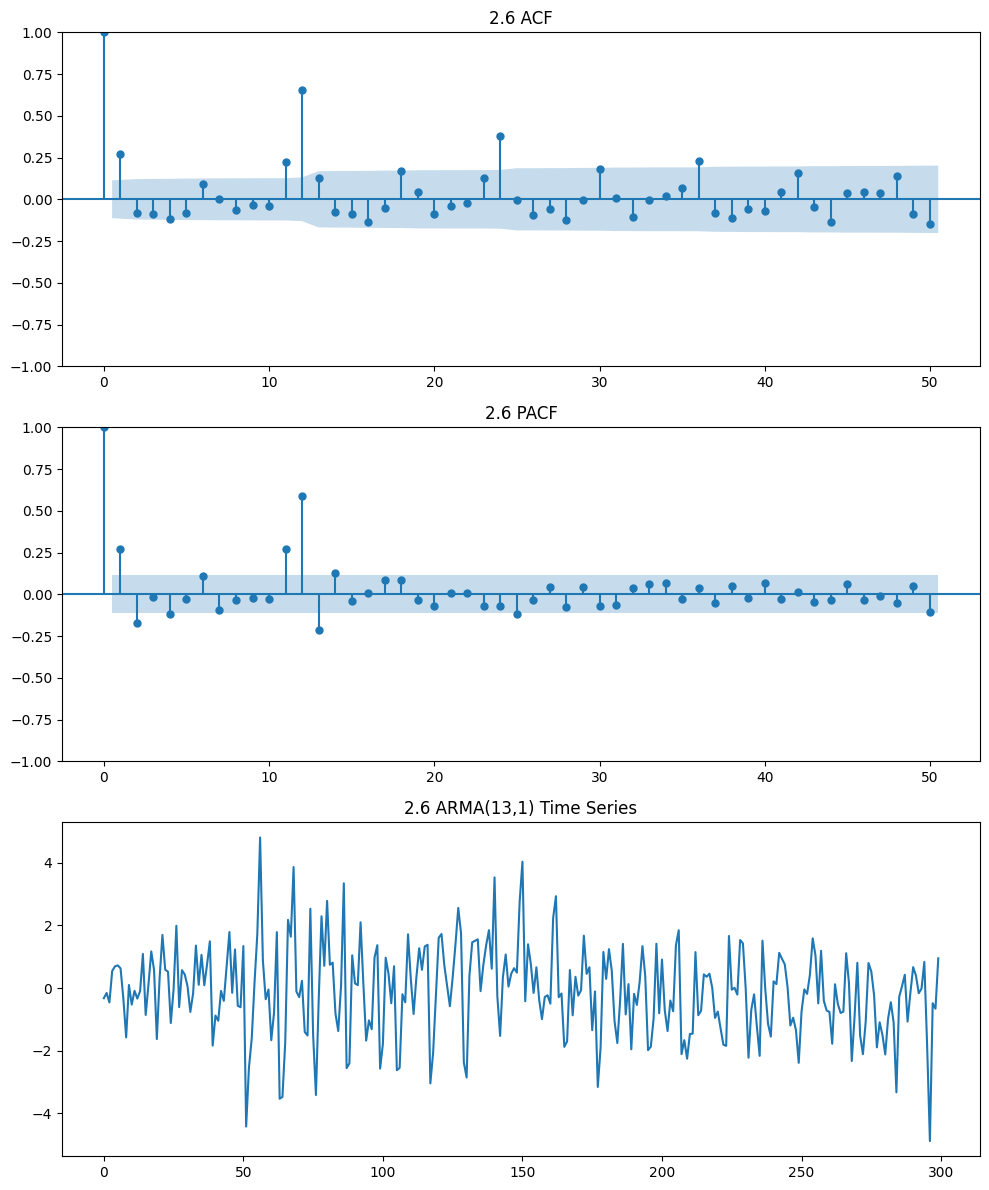

In [323]:
fig2_6, axes2_6 = plt.subplots(3, 1, figsize=(10, 12))
plot_acf(models[5][1], ax=axes2_6[0], lags=50); axes2_6[0].set_title("2.6 ACF")
plot_pacf(models[5][1], ax=axes2_6[1], lags=50); axes2_6[1].set_title("2.6 PACF")
plt.plot(models[5][1]); plt.title("2.6 ARMA(13,1) Time Series")
plt.tight_layout()
plt.savefig("2_6_individual.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.7

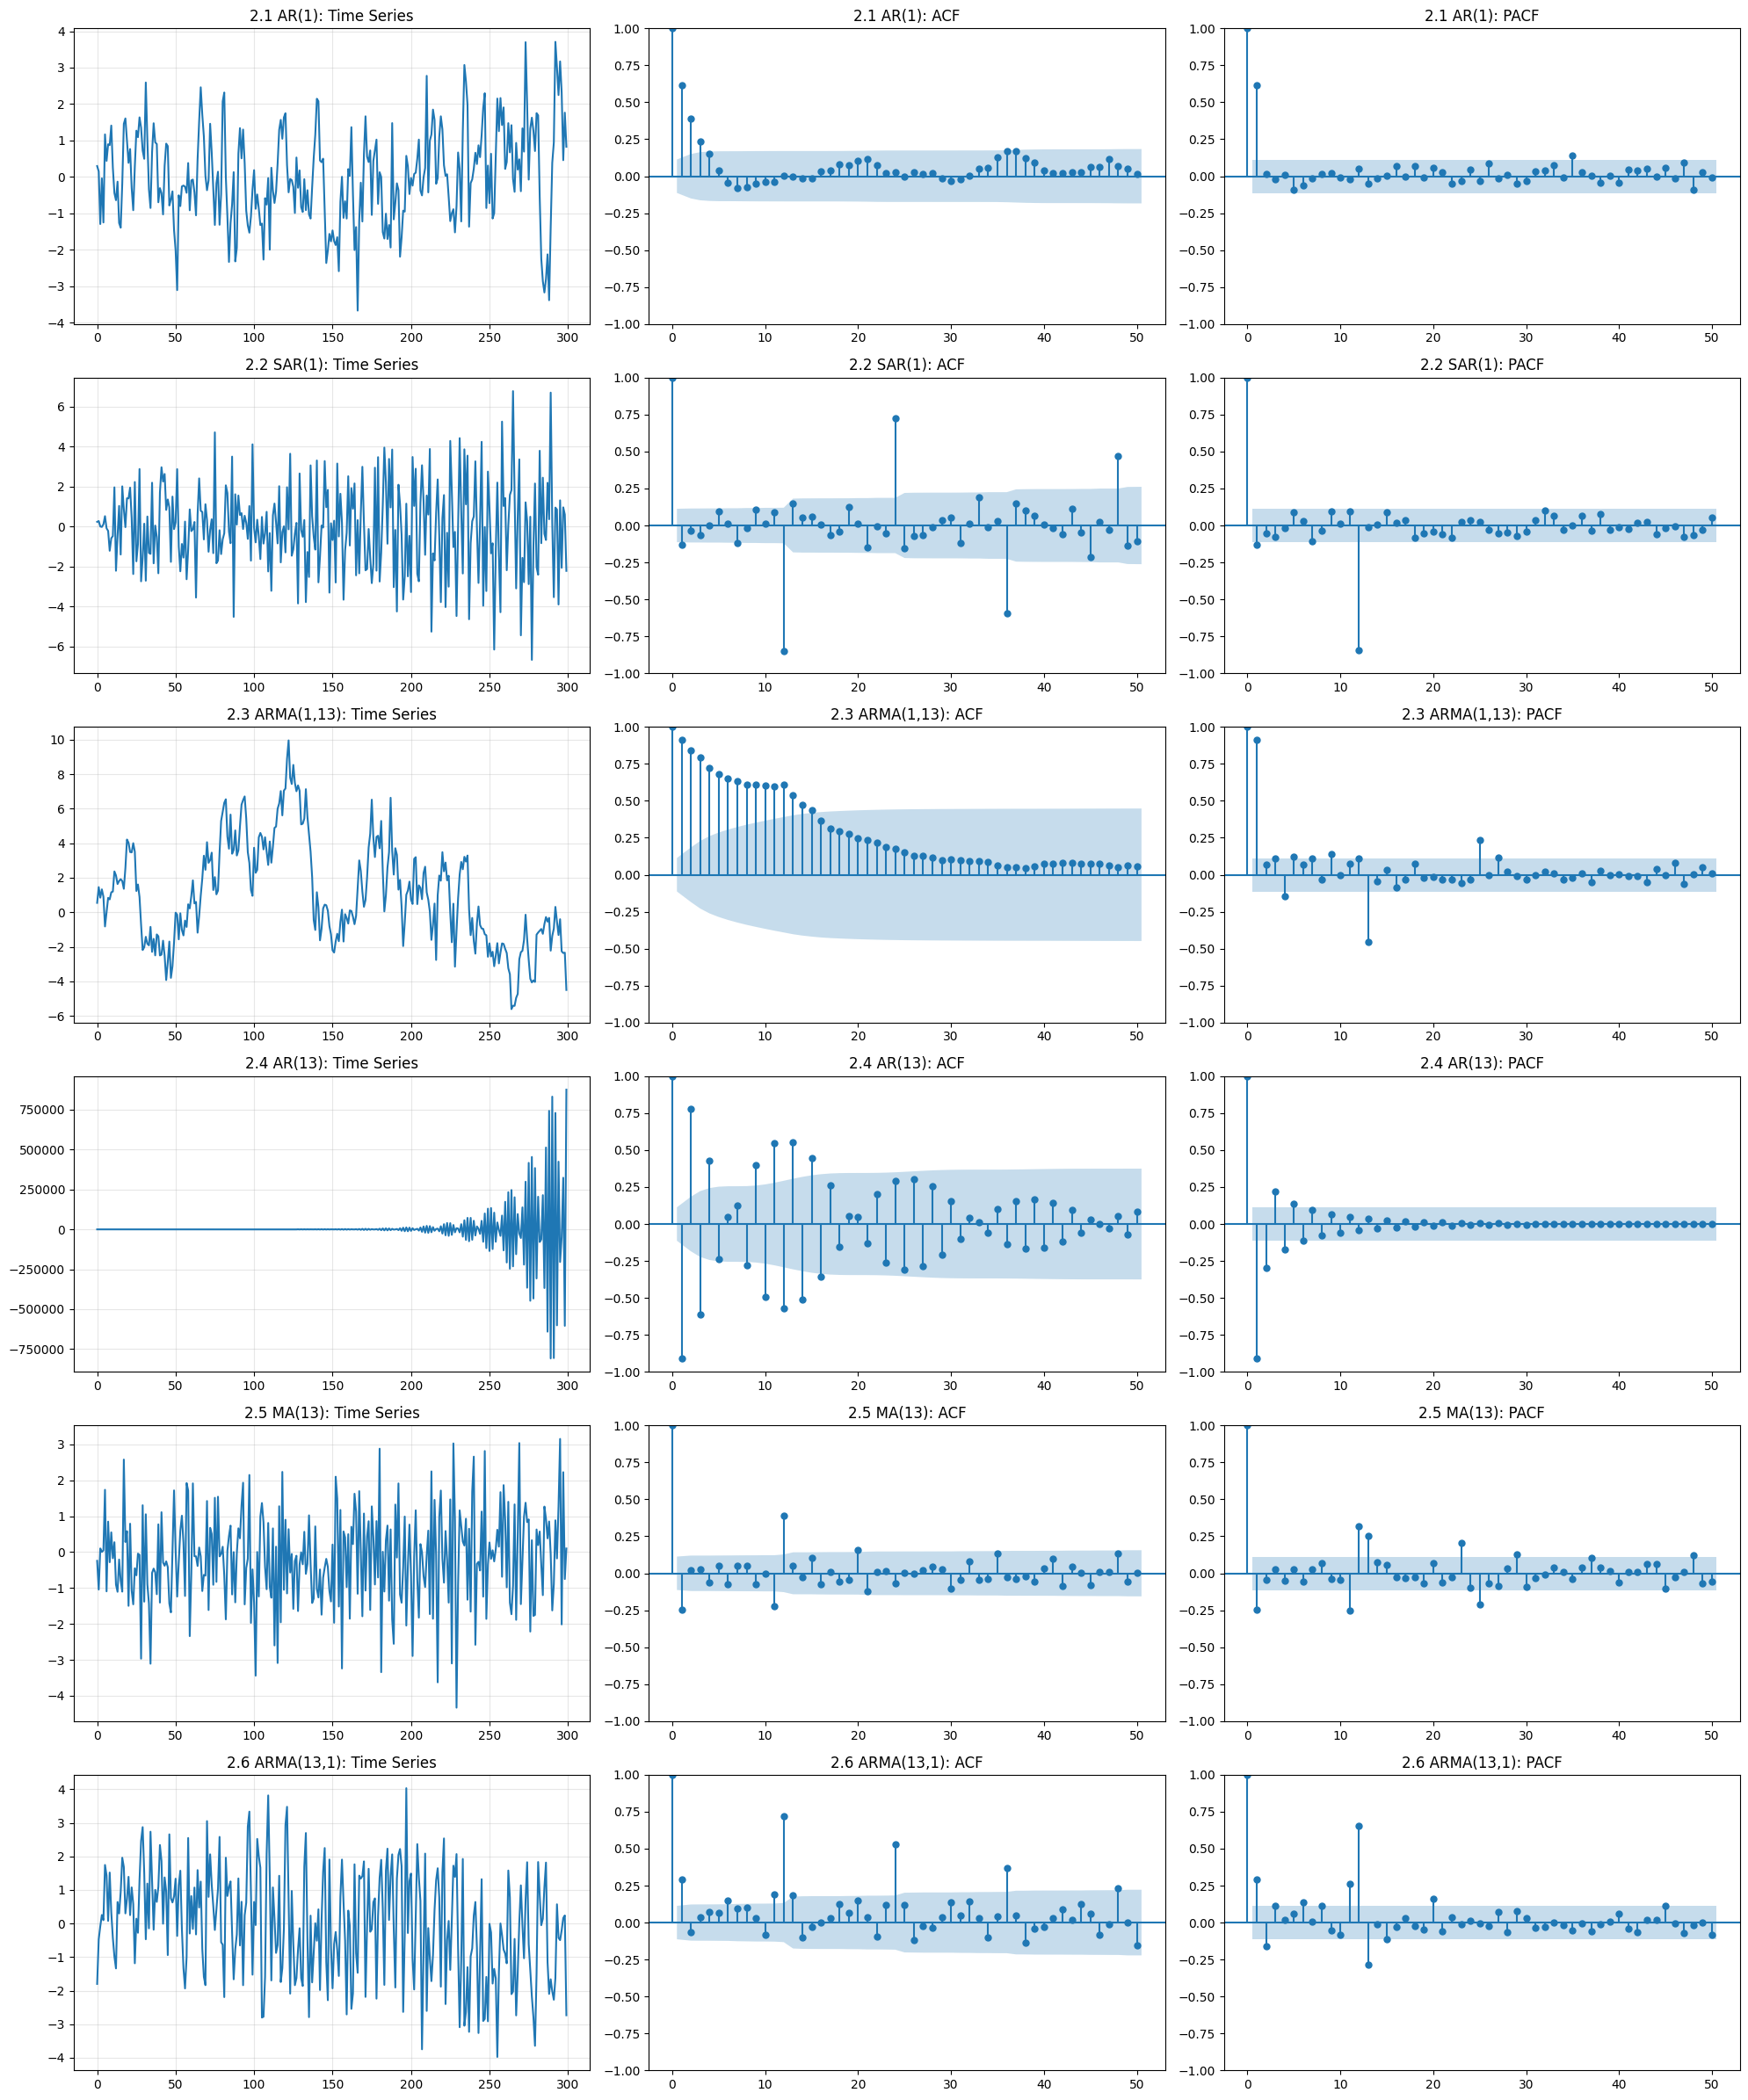

In [13]:
fig, axes = plt.subplots(6, 3, figsize=(20, 24))  # 6 models x 3 plots each
axes = axes.flatten()  # Now 18 total axes

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for i, (title, y) in enumerate(models):
    # Time series - subplot 0,3,6,9,12,15
    axes[3*i].plot(y)
    axes[3*i].set_title(f"{title}: Time Series")
    axes[3*i].grid(True, alpha=0.3)
    
    # ACF - subplot 1,4,7,10,13,16
    plot_acf(y, ax=axes[3*i+1], lags=50)
    axes[3*i+1].set_title(f"{title}: ACF")
    
    # PACF - subplot 2,5,8,11,14,17
    plot_pacf(y, ax=axes[3*i+2], lags=50)
    axes[3*i+2].set_title(f"{title}: PACF")

plt.tight_layout()
plt.savefig("section2_fixed.png", dpi=300, bbox_inches="tight")
plt.show()